# step 1 : library imports and load data
In this section, we import necessary libraries for data manipulation and visualization. We also load the train.csv and store.csv datasets.

In [ ]:
!git clone https://github.com/ML-Proj-Team/Rossmann_Sales.git


Cloning into 'Rossmann_Sales'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 10 (delta 0), reused 10 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), 6.98 MiB | 11.64 MiB/s, done.


In [ ]:
%cd /content/Rossmann_Sales/dataset


/content/Rossmann_Sales/dataset


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the datasets
train = pd.read_csv('train.csv', low_memory=False)
store = pd.read_csv('store.csv')

print("Data loaded successfully.")

Data loaded successfully.


# step 2 : data merging

We merge the train and store dataframes on the Store column.
This allows us to:

1- analyze how store-specific features (like StoreType) affect sales performance.

2- convert the Date column to a proper datetime format.

In [ ]:
# Convert Date to datetime
train['Date'] = pd.to_datetime(train['Date'])

# Merge datasets
df = pd.merge(train, store, on='Store')
df.head()


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


# Step 3: Sales Trend Analysis (task 1)
We visualize the daily sales trend to identify patterns and seasonality. We will compare the sales of three different stores over time.

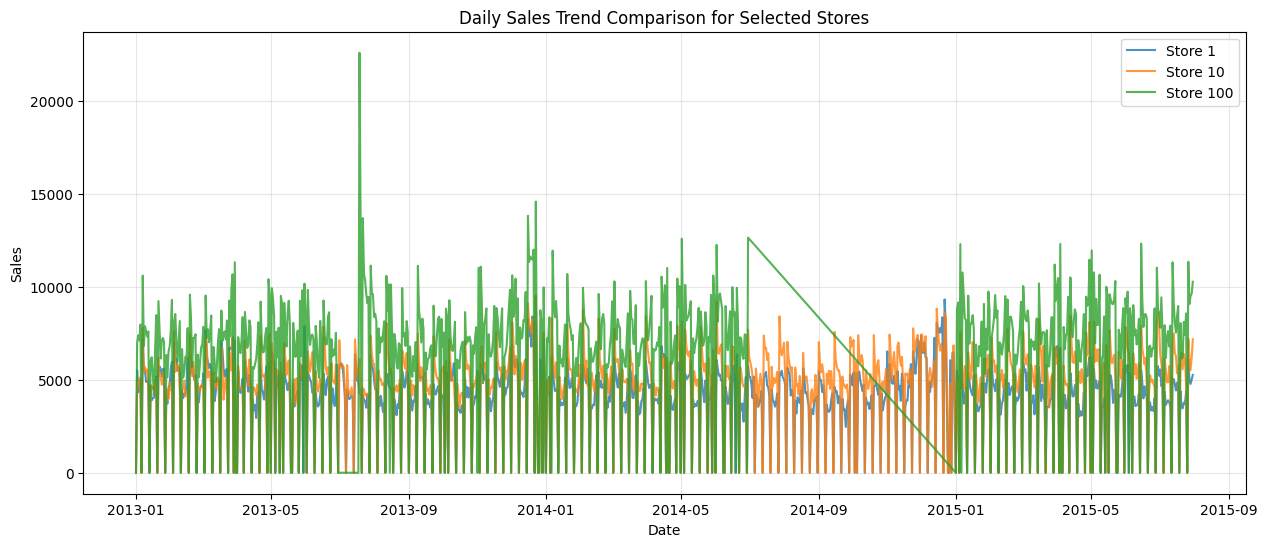

In [ ]:
# Visualizing Sales Trend over time for sample stores
plt.figure(figsize=(15, 6))

# Selecting 3 sample stores
sample_stores = [1, 10, 100]

for s in sample_stores:
    store_data = df[df['Store'] == s].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Sales'], label=f'Store {s}', alpha=0.8)

plt.title('Daily Sales Trend Comparison for Selected Stores')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## visualization clearer and reduce noise

1- Exclude days when stores were **closed**.

2- Apply a 7-day **rolling average** to smooth out daily fluctuations and highlight the underlying sales trend.

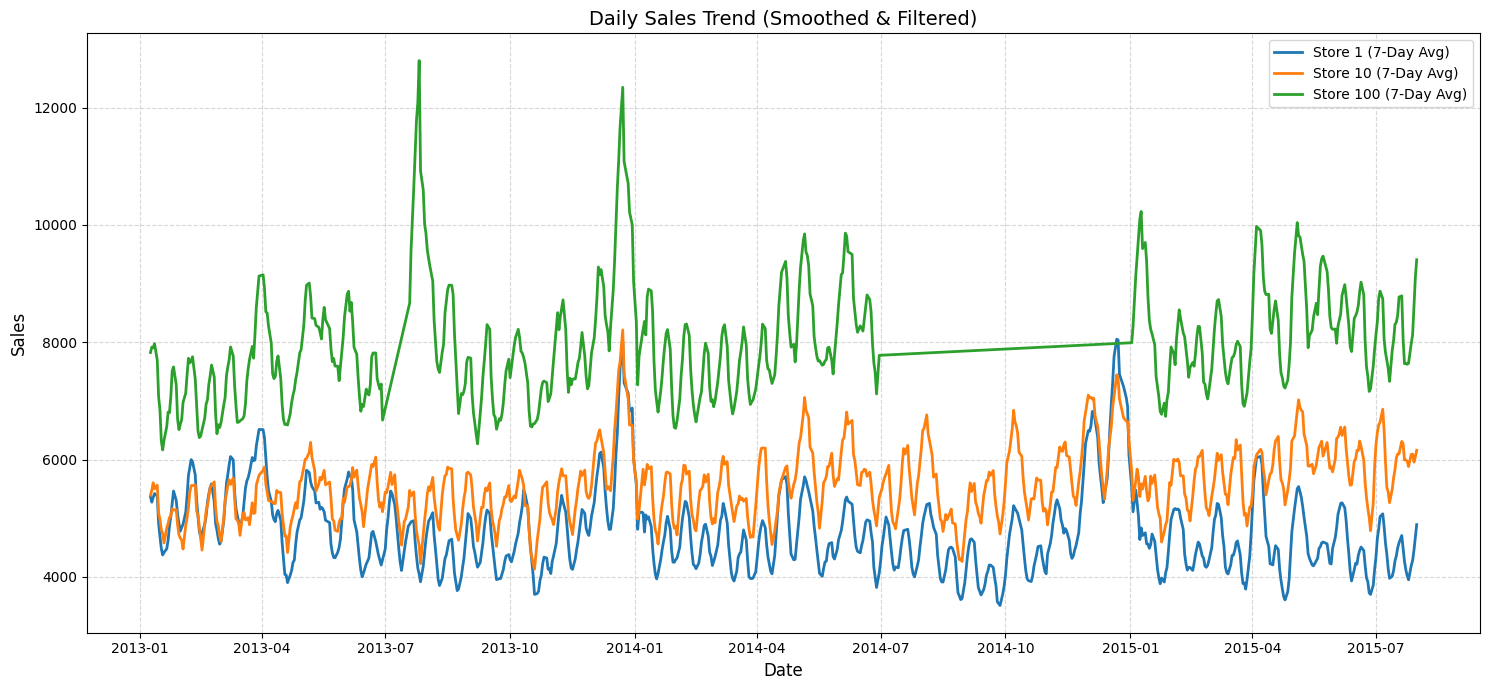

In [ ]:
plt.figure(figsize=(15, 7))

# Selecting sample stores to compare
sample_stores = [1, 10, 100]

for s in sample_stores:
    # Filter data for the specific store
    store_data = df[df['Store'] == s].sort_values('Date').copy()

    # IMPORTANT: Remove days where store was closed to clean the chart
    store_data = store_data[store_data['Open'] != 0]

    # Calculate 7-day rolling average for smoothing
    store_data['Sales_Moving_Avg'] = store_data['Sales'].rolling(window=7).mean()

    # Plot the smoothed data
    plt.plot(store_data['Date'], store_data['Sales_Moving_Avg'], label=f'Store {s} (7-Day Avg)', linewidth=2)

plt.title('Daily Sales Trend (Smoothed & Filtered)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# step 4 : impact of promotions (task 2)

/tmp/ipython-input-3746853951.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Promo', y='Sales', palette='viridis')


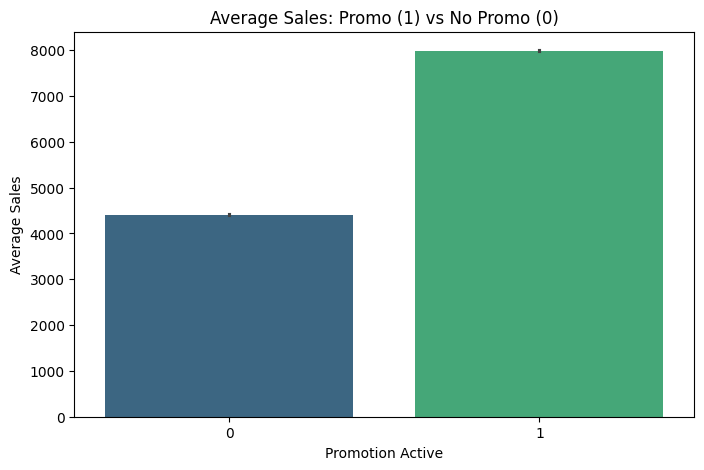

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Promo', y='Sales', palette='viridis')
plt.title('Average Sales: Promo (1) vs No Promo (0)')
plt.xlabel('Promotion Active')
plt.ylabel('Average Sales')
plt.show()

# Step 5: Correlation Matrix (Task 3)
We use a heatmap to visualize the correlation between numerical features. This helps us understand which variables (like Customers or Promo) have the strongest relationship with Sales.

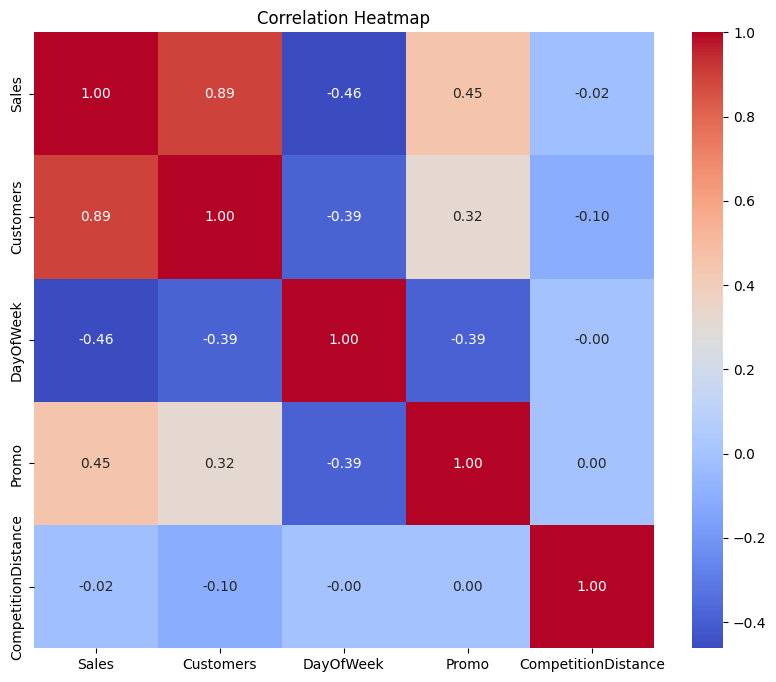

In [ ]:
plt.figure(figsize=(10, 8))
# Analyzing key numerical features
cols_to_corr = ['Sales', 'Customers', 'DayOfWeek', 'Promo', 'CompetitionDistance']
correlation = df[cols_to_corr].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()